In [2]:
import pandas as pd

df = pd.read_csv("data/merged_dataset.csv")
df.head()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003 non-null  int64
dtypes: i

Matplotlib is building the font cache; this may take a moment.


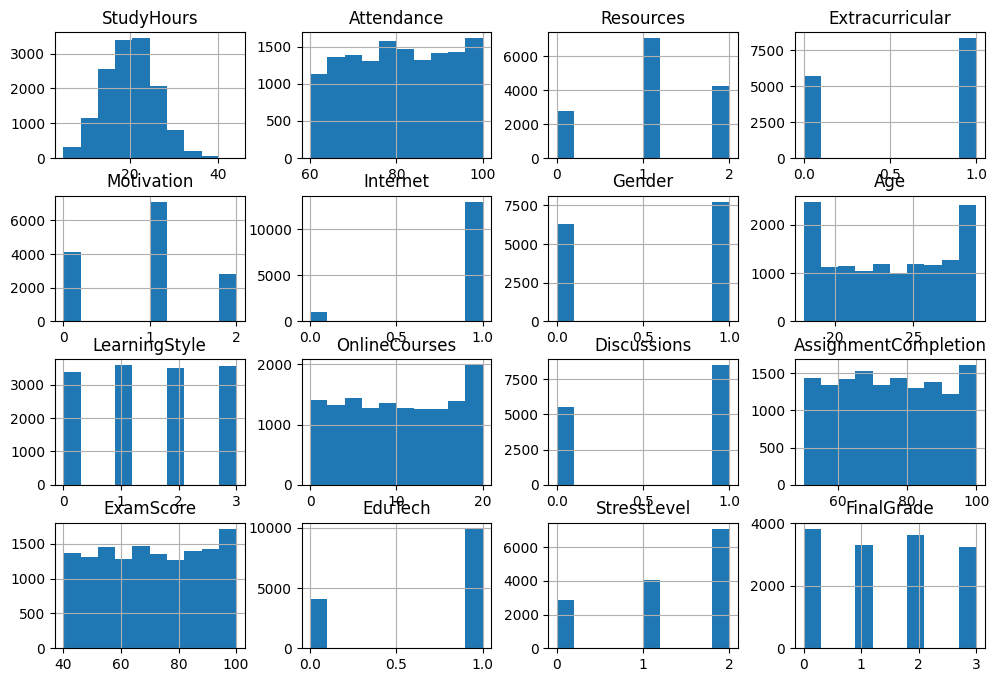

In [4]:
df.describe()
df.isnull().sum()
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.show()



In [ ]:
df.columns
# CALCULATE AVERAGES
average_exam_score = df['ExamScore'].mean()
average_attendance = df['Attendance'].mean()

average_exam_score, average_attendance


,ExamScore,average_score,total_score
0,40,40,40
1,66,66,66
2,99,99,99
3,40,40,40
4,66,66,66


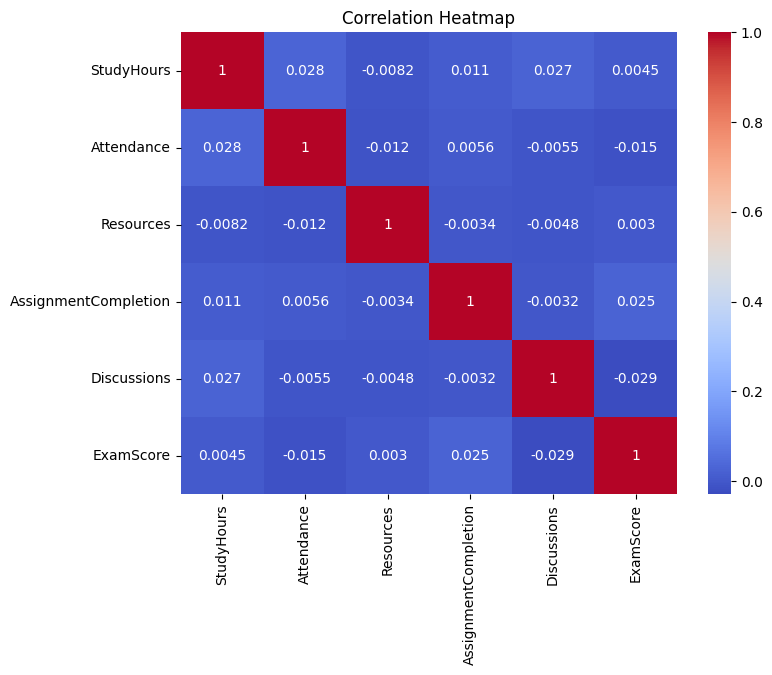

In [ ]:
#CORRELATION ANALYSIS (Heatmap)
import seaborn as sns
import matplotlib.pyplot as plt

corr_features = [
    'StudyHours', 'Attendance', 'Resources',
    'AssignmentCompletion', 'Discussions',
    'ExamScore'
]

corr = df[corr_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



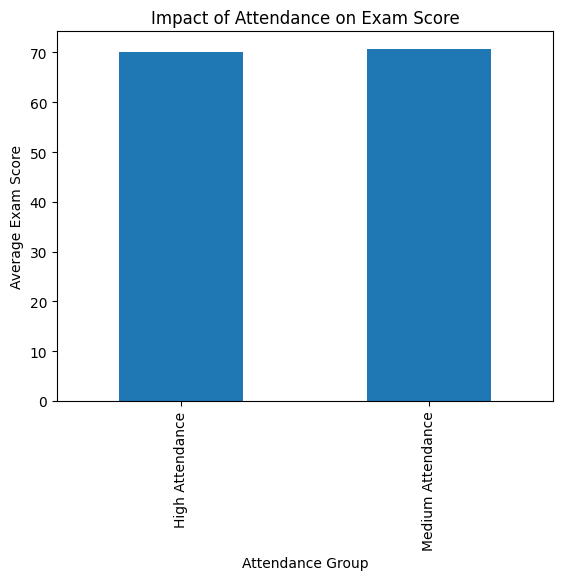

In [14]:
#ABSENTEE IMPACT ANALYSIS
def attendance_group(att):
    if att >= 75:
        return 'High Attendance'
    elif att >= 50:
        return 'Medium Attendance'
    else:
        return 'Low Attendance'

df['attendance_group'] = df['Attendance'].apply(attendance_group)
attendance_impact = df.groupby('attendance_group')['ExamScore'].mean()
attendance_impact
attendance_impact.plot(kind='bar')
plt.title('Impact of Attendance on Exam Score')
plt.xlabel('Attendance Group')
plt.ylabel('Average Exam Score')
plt.show()


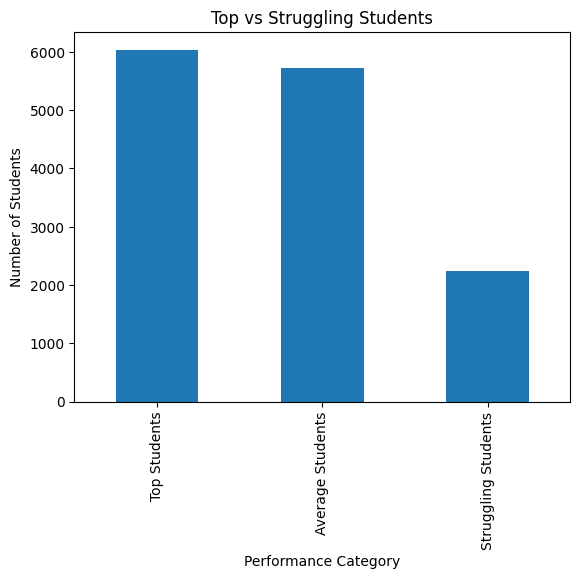

In [16]:
#Mark
def performance_level(score):
    if score >= 75:
        return 'Top Students'
    elif score >= 50:
        return 'Average Students'
    else:
        return 'Struggling Students'

df['performance_level'] = df['ExamScore'].apply(performance_level)
performance_counts = df['performance_level'].value_counts()
performance_counts
performance_counts.plot(kind='bar')
plt.title('Top vs Struggling Students')
plt.xlabel('Performance Category')
plt.ylabel('Number of Students')
plt.show()

